In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("Data04_Employee_Attrition.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
df.duplicated().sum()

np.int64(3008)

In [ ]:
categorical=df.select_dtypes(include="object").columns
categorical

Index(['Department', 'salary'], dtype='object')

In [ ]:
numeric=df.select_dtypes(exclude="object").columns
numeric

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years'],
      dtype='object')

In [ ]:
df.describe(include="object")

,Department,salary
count,14999,14999
unique,10,3
top,sales,low
freq,4140,7316


In [ ]:
df["Department"].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [ ]:
df["salary"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [ ]:
df["Department"].value_counts()

,count
Department,
sales,4140
technical,2720
support,2229
IT,1227
product_mng,902
marketing,858
RandD,787
accounting,767
hr,739


In [ ]:
df["salary"].value_counts()

,count
salary,
low,7316
medium,6446
high,1237


In [ ]:
df["Department"].value_counts(normalize=True)

,proportion
Department,
sales,0.276018
technical,0.181345
support,0.148610
IT,0.081805
product_mng,0.060137
marketing,0.057204
RandD,0.052470
accounting,0.051137
hr,0.049270


In [ ]:
df["salary"].value_counts(normalize=True)

,proportion
salary,
low,0.487766
medium,0.429762
high,0.082472


<Axes: xlabel='Department'>

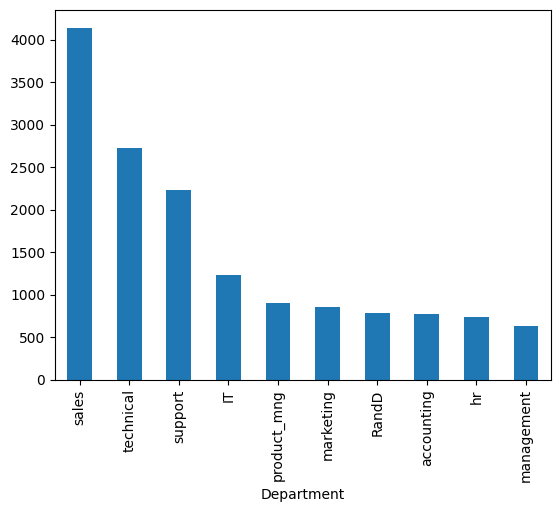

In [ ]:
df["Department"].value_counts().plot(kind="bar")

<Axes: xlabel='salary'>

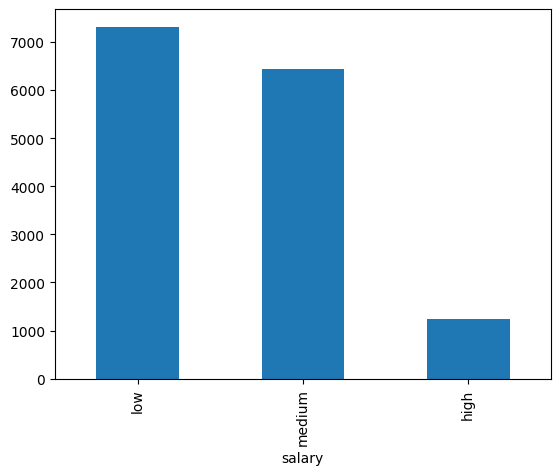

In [ ]:
df["salary"].value_counts().plot(kind="bar")

In [ ]:
df["left"].value_counts()

,count
left,
0,11428
1,3571


In [ ]:
#How to handle imbalanced Dataset?
#1. Use the same dataset don't do any changes
#2. Then use under sampling
#3. at last use Over sampling/ SMOTE

In [ ]:
df1=df.drop_duplicates()
df1

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high
11998,0.33,0.65,3,172,10,0,0,1,marketing,high


In [ ]:
df1.duplicated().any()

np.False_

In [ ]:
#Categorical---> Numeric Data Transfroation:
#One Hot Encoding vs Label Encoding
#Lable Encoding
''' Because of Ordinality(ordering) it becomes biased to higher values'''
#One Hot Encoding
'''It increases computing cost'''

'It increases computing cost'

In [ ]:
"""Feature Scaling:
To bring all the features on the same scale.Types:
1. Normalization
2. Standardization
----------------------------------------------Till Here-----------------------------------------------------------------------
"""

'Feature Scaling:\nTo bring all the features on the same scale.Types:\n1. Normalization\n2. Standardization\n----------------------------------------------Till Here-----------------------------------------------------------------------\n'

In [ ]:
"""Grid Search CV should be used for Large Data Set but takes a lot of time/ resources to give the result
So mostly Grid is used for short Data set with lesser parameters. And for large Data set with larger parameters use Ramdomization CV
"""

'Grid Search CV should be used for Large Data Set but takes a lot of time/ resources to give the result\nSo mostly Grid is used for short Data set with lesser parameters. And for large Data set with larger parameters use Ramdomization CV\n'

In [ ]:
'''Feature Engineering
1. Label Encoding
2. Feature Engineering'''

'Feature Engineering\n1. Label Encoding\n2. Feature Engineering'

In [ ]:
X=df1.drop("left",axis=1)
y=df1["left"]

Label Encoding:

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

X["Department"]=le.fit_transform(X["Department"])
X["salary"]=le.fit_transform(X["salary"])

One Hot Encoding:

In [ ]:
cat_cols=["Department","salary"]
X_final=pd.get_dummies(X,columns=cat_cols,drop_first=True)
X_final

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,1,False,False,False,True,False,False,False,False,False,False,False
11996,0.74,0.95,5,266,10,0,1,False,False,False,True,False,False,False,False,False,False,False
11997,0.85,0.54,3,185,10,0,1,False,False,False,True,False,False,False,False,False,False,False
11998,0.33,0.65,3,172,10,0,1,False,False,False,False,True,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_final,y,random_state=42, test_size=0.3,stratify=y)
print("X test Shape:",X_test.shape)
print("X train Shape:",X_train.shape)
print("y test Shape:",y_test.shape)
print("y train Shape:",y_train.shape)



X test Shape: (3598, 18)
X train Shape: (8393, 18)
y test Shape: (3598,)
y train Shape: (8393,)


Fature Scalling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
std_scalar=StandardScaler()


In [ ]:
x_train_scaled=std_scalar.fit_transform(X_train)
x_test_scaled=std_scalar.transform(X_test)

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow import keras

In [ ]:
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
from keras.layers import Input, Dense, Dropout
from keras.models import Sequential

classifier = Sequential()
classifier.add(Input(shape=(18,)))  # Explicit input layer
classifier.add(Dense(9, kernel_initializer="uniform", activation="relu"))
classifier.add(Dropout(0.3))  # optional dropout for regularization
classifier.add(Dense(1, kernel_initializer="uniform", activation="sigmoid"))

classifier.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# Training the model
classifier.fit(x_train_scaled, y_train, batch_size = 300, epochs = 50)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7267 - loss: 0.6893
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8338 - loss: 0.6705
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - loss: 0.6389
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8354 - loss: 0.5917
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8350 - loss: 0.5369
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8336 - loss: 0.4878
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8386 - loss: 0.4474
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8331 - loss: 0.4206
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8446 - loss: 0.3959
Epoch 10/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8495 - loss: 0.3777
Epoch 11/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8526 - loss: 0.3656
Epoch 12/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8453 - lo

In [ ]:
y_pred = classifier.predict(x_test_scaled)
y_pred

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.01881235],
       [0.18533167],
       [0.00227072],
       ...,
       [0.23019464],
       [0.08372817],
       [0.18544845]], dtype=float32)

In [ ]:
y_pred_classifier = (y_pred > 0.5)
y_pred_classifier

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

<Axes: >

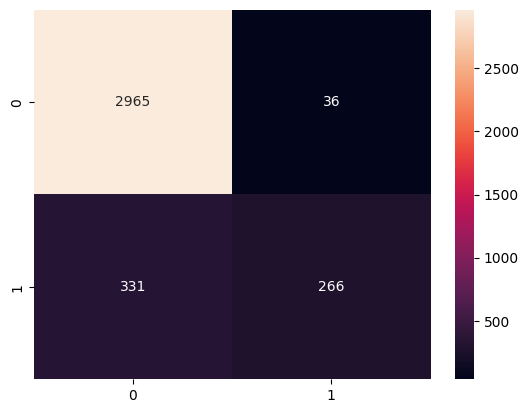

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_classifier)
cm
import seaborn as sns
sns.heatmap(cm, annot = True, fmt = 'd')

In [ ]:
from sklearn.metrics import classification_report
cr = classification_report(y_test, y_pred_classifier)
print(cr)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3001
           1       0.88      0.45      0.59       597

    accuracy                           0.90      3598
   macro avg       0.89      0.72      0.77      3598
weighted avg       0.90      0.90      0.88      3598



In [ ]:
input_data = [0.26,0.7,3,238,6,0,0,0,0,0,0,0,0,0,1,0,0,1]

new_pred = classifier.predict(std_scalar.transform(np.array([[0.26,0.7,3,238,6,0,0,0,0,0,0,0,0,0,1,0,0,1]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
new_pred
new_pred = (new_pred > 0.5)
new_pred

array([[False]])

In [ ]:
!pip install scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score


In [ ]:
def make_classifier():
    classifier = Sequential()
    classifier.add(Dense(9, kernel_initializer = "uniform", activation = "relu", input_dim=18))
    classifier.add(Dense(1, kernel_initializer = "uniform", activation = "sigmoid"))
    classifier.compile(optimizer= "adam",loss = "binary_crossentropy", metrics = ["accuracy"])
    return classifier



In [ ]:
classifier01 = KerasClassifier(model = make_classifier, batch_size=10, epochs=1)

In [ ]:
from scikeras.wrappers import KerasClassifier
print(KerasClassifier.__module__)

scikeras.wrappers


In [ ]:
pip install --upgrade scikit-learn scikeras

In [ ]:
%%time
print('hello')

hello
CPU times: user 100 µs, sys: 15 µs, total: 115 µs
Wall time: 122 µs


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scikeras.wrappers import KerasClassifier

In [ ]:
def build_classifier():
    classifier = Sequential()
    classifier.add(Dense(9, kernel_initializer="uniform", activation="relu", input_dim=18))
    classifier.add(Dense(1, kernel_initializer="uniform", activation="sigmoid"))
    classifier.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return classifier

In [ ]:
keras_clf = KerasClassifier(model=build_classifier, epochs=50, batch_size=300, verbose=0)

In [ ]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
accuracies  = cross_val_score(keras_clf, x_train_scaled, y_train, cv=kfold)
accuracies


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo

array([0.89994044, 0.95771292, 0.89398451, 0.83432658, 0.83373063])

In [ ]:
accuracies

array([0.89994044, 0.95771292, 0.89398451, 0.83432658, 0.83373063])

In [ ]:
mean_acc = accuracies.mean()
mean_acc

np.float64(0.8839390181311453)

In [ ]:
accuracies.var() # small variance model is working good

np.float64(0.0021563645846097382)

In [ ]:
from keras.layers import Dropout
DL_model2 = Sequential()
DL_model2.add(Input(shape=(18,)))
DL_model2.add(Dense(9, kernel_initializer = "uniform", activation = "relu"))
DL_model2.add(Dropout(rate = 0.1))
DL_model2.add(Dense(1, kernel_initializer = "uniform", activation = "sigmoid"))
DL_model2.compile(optimizer= "adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [ ]:
DL_model2.fit(x_train_scaled, y_train, batch_size = 100, epochs = 10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7889 - loss: 0.6775
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8346 - loss: 0.5689
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8362 - loss: 0.4414
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8360 - loss: 0.3758
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8392 - loss: 0.3405
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8418 - loss: 0.3205
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.2981
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8686 - loss: 0.2961
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8748 - loss: 0.2827
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8713 - loss: 0.2717


In [ ]:
from sklearn.model_selection import GridSearchCV
def make_classifier_01(optimizer):
    classifier = Sequential()
    classifier.add(Dense(9, kernel_initializer = "uniform", activation = "relu", input_dim=18))
    classifier.add(Dense(1, kernel_initializer = "uniform", activation = "sigmoid"))
    classifier.compile(optimizer= optimizer,loss = "binary_crossentropy",metrics = ["accuracy"])
    return classifier

In [ ]:
model=KerasClassifier(model=make_classifier_01)
params = {
       'model__optimizer':['adam','rmsprop']
}

In [ ]:
%%time
grid_search = GridSearchCV(estimator=model,
                           param_grid=params,
                           scoring="accuracy",
                           cv=2)
grid_result=grid_search.fit(x_train_scaled, y_train)

best_param = grid_result.best_params_
best_accuracy = grid_result.best_score_

print('Best Parameters = ', best_param)
print('Best accuaracy = ', best_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8346 - loss: 0.6607
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7793 - loss: 0.6711
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8457 - loss: 0.6578
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8166 - loss: 0.6615
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7859 - loss: 0.6427
Best Parameters =  {'model__optimizer': 'adam'}
Best accuaracy =  0.833909633577754
CPU times: user 8.94 s, sys: 593 ms, total: 9.54 s
Wall time: 9.64 s


In [ ]:
params = {
    'batch_size':[20,35],
    'epochs':[2,3],
    'optimizer':['adam','rmsprop']
}

In [ ]:
grid_search = GridSearchCV(estimator=classifier01,
                           param_grid=params,
                           scoring="accuracy",
                           cv=2)

In [ ]:
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'batch_size': [20, 35], 'epochs': [2, 3], 'optimizer': ['adam', 'rmsprop']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [ ]:
grid_search.fit(X_train_sc, y_train)

NameError: name 'X_train_sc' is not defined

In [ ]:
best_param = grid_search.best_params_
best_accuracy = grid_search.best_score_

print('Best Parameters = ', best_param)
print('Best accuaracy = ', best_accuracy)

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'